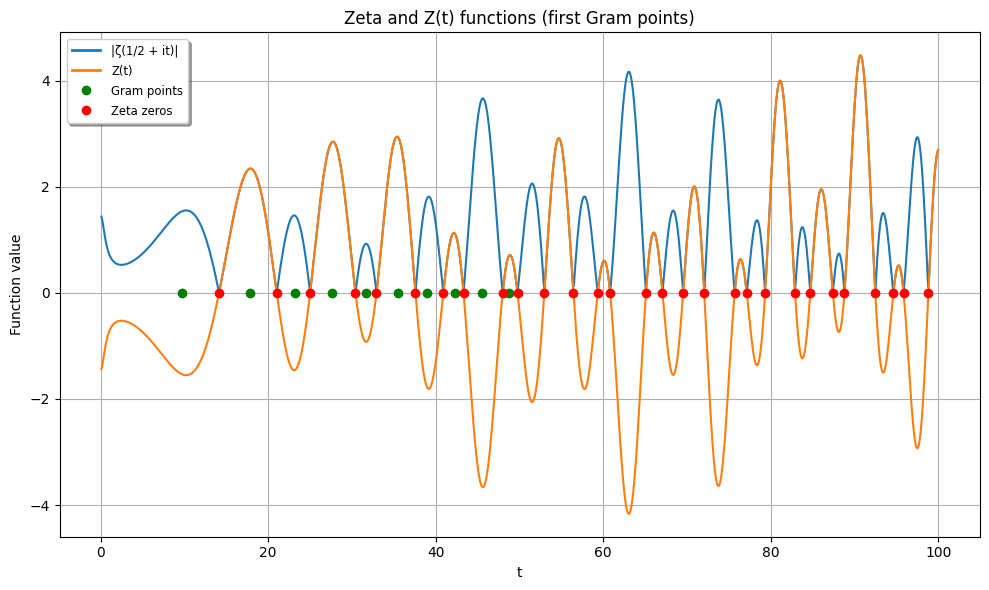

In [ ]:
# Código baseado em "Computing Zeroes of the Riemann Zeta Function"
# Zack Horton, April 13, 2023 — modificado para gerar Gram points diretamente
import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt
import pandas as pd

mp.dps = 15
mp.pretty = True

def graph_zeta():
    zeta_values, z_values, indices = [], [], []
    
    gram_df = pd.read_csv("../dataset/gram_points.csv")
    gram_points = gram_df["gram_point"].tolist()[:10]

    fig, ax = plt.subplots(figsize=(10, 6))

    for t in np.arange(0.1, 100.1, 0.1):
        zeta_val = mp.zeta(0.5 + 1j * t)
        z_val = mp.siegelz(t)
        
        indices.append(float(t))
        zeta_values.append(abs(zeta_val))
        z_values.append(float(z_val))

    zeros = [mp.zetazero(i).imag for i in range(1, 30)]

    ax.grid(True)
    ax.plot(indices, zeta_values, label="|ζ(1/2 + it)|")
    ax.plot(indices, z_values, label="Z(t)")
    ax.plot(gram_points, [0]*len(gram_points), "go", label="Gram points")
    ax.plot(zeros, [0]*len(zeros), "ro", label="Zeta zeros")

    ax.set_title("Zeta and Z(t) functions (first Gram points)")
    ax.set_xlabel("t")
    ax.set_ylabel("Function value")

    leg = ax.legend(shadow=True)
    for t in leg.get_texts():
        t.set_fontsize("small")
    for l in leg.get_lines():
        l.set_linewidth(2.0)

    plt.tight_layout()
    plt.show()

graph_zeta()
